In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skills: ast.literal_eval(skills) if not pd.isna(skills) else skills)

c:\Users\Felipe Novais\.conda\envs\data_jobs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Exercise: Calculate the top 5 skills for Data Analysts per month

In [2]:
# data filtering

filtered_df = df.loc[
    (df["job_title_short"].isin(["Data Analyst", "Senior Data Analyst"])) & (df["job_skills"].notna()),
    ["job_title_short", "job_skills", "job_posted_date"]
]

In [3]:
filtered_df["job_posted_month"] = filtered_df["job_posted_date"].dt.month
filtered_df.drop(columns=["job_posted_date"], inplace=True)
filtered_df

,job_title_short,job_skills,job_posted_month
1,Data Analyst,"[r, python, sql, nosql, power bi, tableau]",1
12,Data Analyst,"[sql, php, excel, power bi, sap, jira]",12
18,Data Analyst,"[sql, python, r, redshift, pandas, excel, look...",10
25,Senior Data Analyst,[sql],6
31,Data Analyst,[sql],10
...,...,...,...
785685,Data Analyst,"[sql, excel]",7
785691,Data Analyst,"[sql, python, shell, sql server, tableau, micr...",1
785705,Data Analyst,"[sql, python, tableau]",1
785717,Data Analyst,"[aws, azure]",3


In [13]:
# explode dataframe and pivot

explode_df = filtered_df.explode("job_skills")

aggregation_df = explode_df.pivot_table(index="job_posted_month", columns="job_skills", aggfunc="size", fill_value=0)

In [32]:
# add total row for data filtering

aggregation_df.loc["Total"] = aggregation_df.sum()
aggregation_df_sorted = aggregation_df.sort_values(by="Total", axis=1, ascending=False)

aggregation_df_sorted.iloc[
    :,
    :5
]

job_skills,sql,excel,python,tableau,power bi
job_posted_month,,,,,
1,13587,9334,7969,6872,5012
2,9701,6617,5744,4901,3840
3,9482,6476,5681,4991,3677
4,9011,6183,5414,4581,3561
5,7830,5351,4872,3976,3087
6,9006,6435,5633,4675,3747
7,9120,6139,5757,4772,3877
8,10605,7240,6694,5502,4416
9,8032,5465,5002,4105,3618


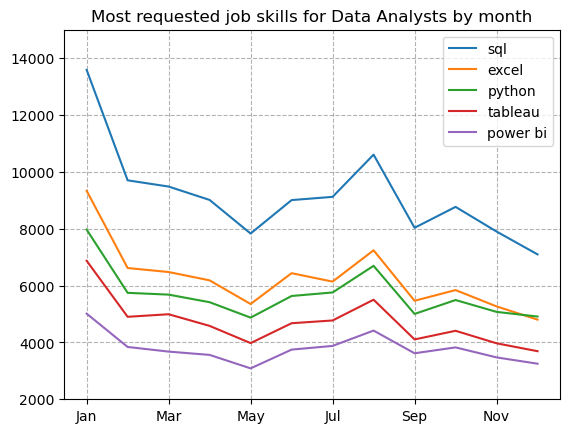

In [64]:
import calendar

final_df = aggregation_df_sorted.iloc[:len(aggregation_df_sorted) - 1,:5].reset_index()

# changing month numbers do abbrevations
final_df["job_posted_month"] = [calendar.month_abbr[month] for month in final_df["job_posted_month"]]

# general formatting
final_df.plot(kind="line", x="job_posted_month")
plt.title("Most requested job skills for Data Analysts by month")
plt.grid(True, color="gray", alpha=0.6, linestyle="--")
plt.ylim(2000, 15000)
plt.xlabel("")
plt.legend(title="")
plt.show()